In [10]:
import os
import numpy as np
import sys
from pathlib import Path
from src.prometheus_io import prom_query_range, prom_query_instant, test_connection 
import src.prometheus_io as pio
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt
import pandas as pd
import re

In [11]:
df = pd.read_csv('../exports/intensive_search_eda.csv')
df

,timestamp,cpu_by_svc__series_0 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.8oss0ybm44rk9qstbv2er3xu3.qrgljd8a8m4q7uockx8ep09sd'},cpu_by_svc__series_1 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.eaxfwhx09aj4komi6zsd3ewhj.raov03xzftsjeeg1gkuvhlm3s'},cpu_by_svc__series_2 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.r74oogu6jmq0vh03nkm5i6i26.o5p9k6nhqjyg5d1nu50w5m83m'},cpu_by_svc__series_3 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.x4tglh5k2fh3tulf079kq1ynf.qc8opx9d26852rf5inrhb8lvu'},cpu_by_svc__series_4 {'container_label_com_docker_swarm_task_name': 'chat-eda_elasticsearch.1.8kjznosyqcuh617coqvnq8vfd'},cpu_by_svc__series_5 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.1.qt0rxxkbu87qaag4f66qnyhdx'},cpu_by_svc__series_6 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.2.julhyc7mfuyl3prif9tv0jj1f'},cpu_by_svc__series_7 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.3.9z6580vratwm3q5qeggdu6nlo'},cpu_by_svc__series_8 {'container_label_com_docker_swarm_task_name': 'chat-eda_kafka.1.m0rysujr4qqgxqezzjryx4f05'},...,"http_rt_latency__k6_http_req_duration_p95 {'error': 'dial: connection refused', 'error_code': '1212', 'expected_response': 'false', 'method': 'GET', 'name': 'users_search', 'scenario': 'default', 'status': '0', 'url':","http_rt_latency__k6_http_req_duration_p95 {'error': 'dial: connection refused', 'error_code': '1212', 'expected_response': 'false', 'method': 'POST', 'name': 'signup', 'scenario': 'default', 'status': '0', 'url': 'sig","http_rt_latency__k6_http_req_duration_p95 {'error': 'dial: i/o timeout', 'error_code': '1211', 'expected_response': 'false', 'method': 'GET', 'name': 'chat_messages_search', 'scenario': 'default', 'status': '0', 'url'","http_rt_latency__k6_http_req_duration_p95 {'error': 'dial: i/o timeout', 'error_code': '1211', 'expected_response': 'false', 'method': 'GET', 'name': 'users_search', 'scenario': 'default', 'status': '0', 'url': 'users","http_rt_latency__k6_http_req_duration_p95 {'error': 'dial: i/o timeout', 'error_code': '1211', 'expected_response': 'false', 'method': 'POST', 'name': 'signup', 'scenario': 'default', 'status': '0', 'url': 'signup'}","http_rt_latency__k6_http_req_duration_p95 {'error_code': '1403', 'expected_response': 'false', 'method': 'GET', 'name': 'chat_messages_search', 'proto': 'HTTP/1.1', 'scenario': 'default', 'status': '403', 'url': 'chat","http_rt_latency__k6_http_req_duration_p95 {'error_code': '1409', 'expected_response': 'false', 'method': 'POST', 'name': 'signup', 'proto': 'HTTP/1.1', 'scenario': 'default', 'status': '409', 'url': 'signup'}","http_rt_latency__k6_http_req_duration_p95 {'expected_response': 'true', 'method': 'GET', 'name': 'chats_me_search', 'proto': 'HTTP/1.1', 'scenario': 'default', 'status': '200', 'url': 'chats_me_search'}","http_rt_latency__k6_http_req_duration_p95 {'expected_response': 'true', 'method': 'GET', 'name': 'users_search', 'proto': 'HTTP/1.1', 'scenario': 'default', 'status': '200', 'url': 'users_search'}","http_rt_latency__k6_http_req_duration_p95 {'expected_response': 'true', 'method': 'POST', 'name': 'login', 'proto': 'HTTP/1.1', 'scenario': 'default', 'status': '200', 'url': 'login'}"
0,2026-04-22 15:05:54.013999939+00:00,0.035704,0.034473,0.033842,0.035338,0.009838,0.0,0.0,0.0,0.026163,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-22 15:05:59.013999939+00:00,0.035704,0.034473,0.035903,0.037098,0.009838,0.0,0.0,0.0,0.026163,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-22 15:06:04.013999939+00:00,0.036338,0.035511,0.035903,0.037098,0.009744,0.0,0.0,0.0,0.027249,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-04-22 15:06:09.013999939+00:00,0.036338,0.035511,0.034472,0.039225,0.009744,0.0,0.0,0.0,0.027249,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-22 15:06:14.013999939+00:00,0.036623,0.036643,0.034472,0.039225,0.009930,0.0,0.0,0.0,0.025892,...,NaN,NaN,NaN,NaN,Na

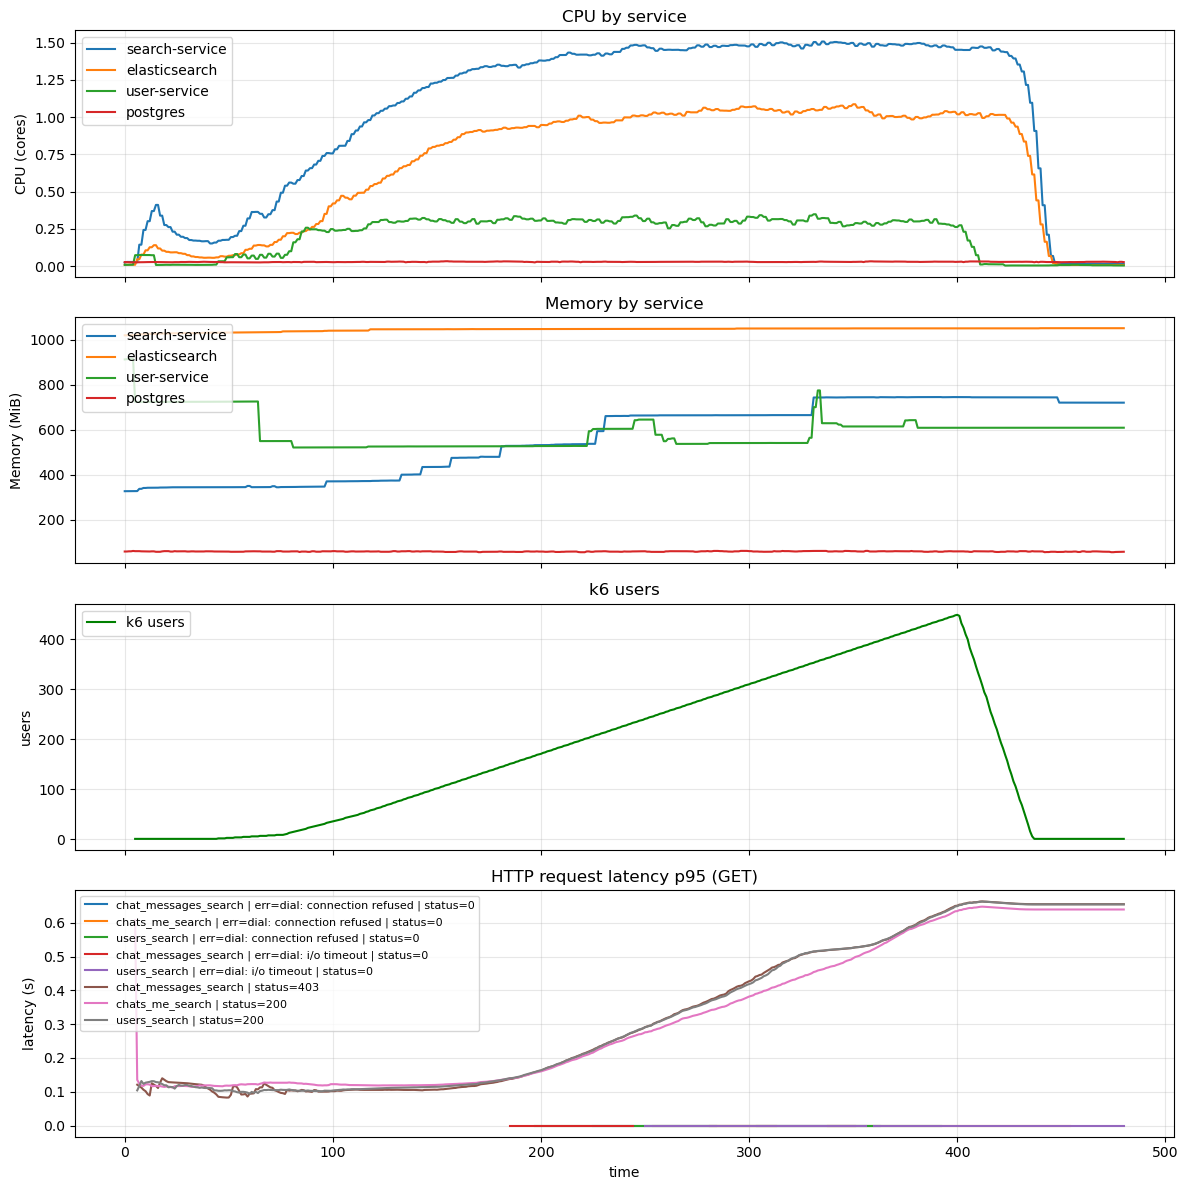

In [18]:
# --- helper: find column containing metric prefix + service name ---
def col_for(metric_prefix: str, service_substring: str) -> str:
    matches = [c for c in df.columns if c.startswith(metric_prefix) and service_substring in c]
    if not matches:
        raise ValueError(f"No column found for prefix='{metric_prefix}' and service='{service_substring}'")
    return matches[0]

services = {
    "search-service": "search-service",
    "elasticsearch": "elasticsearch",
    "user-service": "user-service",
    "postgres": "postgres.1",  # avoids postgres-exporter
}

cpu_cols = {label: col_for("cpu_by_svc__", needle) for label, needle in services.items()}
mem_cols = {label: col_for("mem_by_svc__", needle) for label, needle in services.items()}

# memory in MiB for readability
mem_mib = {label: df[col] / (1024 * 1024) for label, col in mem_cols.items()}

# optional graph: k6 users
k6_users_col = next((c for c in df.columns if c.startswith("k6_users__")), None)

# HTTP latency p95 columns for GET methods only
http_get_latency_cols = [
    c for c in df.columns
    if c.startswith("http_rt_latency__")
    and "'method': 'GET'" in c
]

# nicer label for HTTP latency legend
def latency_label(col: str) -> str:
    name_match = re.search(r"'name': '([^']+)'", col)
    status_match = re.search(r"'status': '([^']+)'", col)
    error_match = re.search(r"'error': '([^']+)'", col)

    name = name_match.group(1) if name_match else "unknown"
    status = status_match.group(1) if status_match else "n/a"

    if error_match:
        return f"{name} | err={error_match.group(1)} | status={status}"
    return f"{name} | status={status}"

# --- plot ---
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(12, 12))

# 1) CPU
for label, col in cpu_cols.items():
    axes[0].plot(df.index, df[col], label=label)
axes[0].set_title("CPU by service")
axes[0].set_ylabel("CPU (cores)")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left")

# 2) Memory
for label, series in mem_mib.items():
    axes[1].plot(df.index, series, label=label)
axes[1].set_title("Memory by service")
axes[1].set_ylabel("Memory (MiB)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left")

# 3) k6 users (optional)
if k6_users_col is not None:
    axes[2].plot(df.index, df[k6_users_col], color="green", label="k6 users")
    axes[2].legend(loc="upper left")
axes[2].set_title("k6 users")
axes[2].set_ylabel("users")
axes[2].grid(True, alpha=0.3)

# 4) HTTP latency p95 (GET only)
# todo the http get latency is only one value, calculate when it crosses the 1000ms 
if http_get_latency_cols:
    for col in http_get_latency_cols:
        axes[3].plot(df.index, df[col], label=latency_label(col))
    axes[3].legend(loc="upper left", fontsize=8)
else:
    axes[3].text(0.5, 0.5, "No GET latency columns found", ha="center", va="center", transform=axes[3].transAxes)

axes[3].set_title("HTTP request latency p95 (GET)")
axes[3].set_ylabel("latency (s)")
axes[3].set_xlabel("time")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# vm_cores = prom_query_range(
#     'count(count(node_cpu_seconds_total{job="chat-monolith-node"}) by (cpu))',
#     START, END, STEP, base_url=PROMETHEUS_URL
# )
# cores = float(vm_cores.iloc[-1, 0]) if not vm_cores.empty else 1.0
# vm_cpu_cores = prom_query_range(
#     f'(1 - avg(rate(node_cpu_seconds_total{{job="chat-monolith-node",mode="idle"}}[1m]))) * {cores}',
#     START, END, STEP, base_url=PROMETHEUS_URL
# )
# java_cpu_cores = prom_query_range(
#     'process_cpu_usage{job="chat-monolith"}',
#     START, END, STEP, base_url=PROMETHEUS_URL
# )
# be_cpu_cores = prom_query_range(
#     'sum(rate(container_cpu_usage_seconds_total{job="chat-monolith-cadvisor",container_label_com_docker_compose_service="app",container!=""}[1m]))',
#     START, END, STEP, base_url=PROMETHEUS_URL
# )
# pg_cpu_cores = prom_query_range(
#     'sum(rate(container_cpu_usage_seconds_total{job="chat-monolith-cadvisor",container_label_com_docker_compose_service="postgres"}[1m]))',
#     START, END, STEP, base_url=PROMETHEUS_URL
# )
# # ---- k6 users (all scenarios) ----
# k6_users = prom_query_range(
#     'sum(k6_vus)',
#     START, END, STEP, base_url=PROMETHEUS_URL
# )
# http_rt_latency = prom_query_range(
#     'avg(k6_http_req_duration_p95{expected_response="true"})',
#     START,
#     END,
#     STEP,
#     base_url=PROMETHEUS_URL,
# )

In [14]:
# ---- CPU chart data prep ----
s_vm = vm_cpu_cores.iloc[:, 0] if not vm_cpu_cores.empty else None
s_app = java_cpu_cores.iloc[:, 0] if not java_cpu_cores.empty else None
s_pg = pg_cpu_cores.iloc[:, 0] if not pg_cpu_cores.empty else None

df = pd.concat(
    [x.rename(n) for x, n in [(s_vm, "vm"), (s_pg, "postgres"), (s_app, "app")] if x is not None],
    axis=1
).interpolate(limit_direction="both")

# ---- 3 rows: CPU (top), HTTP latency (middle), k6 users (bottom) ----
fig, (ax_cpu, ax_lat, ax_k6) = plt.subplots(
    3, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [1.2, 1, 0.8]}
)

# ========== TOP: CPU attribution ==========
ax_cpu.stackplot(
    df.index,
    df["postgres"] if "postgres" in df else 0,
    df["app"] if "app" in df else 0,
    labels=["Postgres (cores)", "App (cores)"],
    alpha=0.55,
)

if not vm_cpu_cores.empty:
    s = vm_cpu_cores.iloc[:, 0]
    ax_cpu.plot(s.index, s.values, lw=1.8, label=f"VM CPU used (cores, max={cores:g})")

ax_cpu.set_title("CPU attribution")
ax_cpu.set_ylabel("CPU used (cores)")
ax_cpu.grid(True, alpha=0.25)
ax_cpu.legend(loc="upper left")

# ========== MIDDLE: HTTP latency ==========
cross_ts = None
cross_val_ms = None

if not http_rt_latency.empty:
    s = http_rt_latency.iloc[:, 0] * 1000  # seconds -> ms
    ax_lat.step(
        s.index, s.values, where="post",
        color="tab:red", linewidth=1.4,
        label="HTTP req duration p95 (ms)"
    )

    # first point where latency exceeds 1000ms
    crossed = s[s > 1000]
    if not crossed.empty:
        cross_ts = crossed.index[0]
        cross_val_ms = float(crossed.iloc[0])
else:
    ax_lat.text(
        0.5, 0.5, "No data in http_rt_latency",
        ha="center", va="center", transform=ax_lat.transAxes
    )

ax_lat.axhline(
    1000, color="tab:blue", linestyle="--", linewidth=1, alpha=0.7,
    label="latency limit 1000ms"
)
ax_lat.set_title("k6 HTTP round-trip latency (p95)")
ax_lat.set_ylabel("Latency (ms)")
ax_lat.grid(True, alpha=0.3)

# ========== BOTTOM: k6 users ==========
if not k6_users.empty:
    s_u = k6_users.iloc[:, 0]
    ax_k6.step(
        s_u.index, s_u.values, where="post",
        color="tab:cyan", lw=1.6, linestyle="--", label="k6 users (VUs)"
    )
else:
    ax_k6.text(
        0.5, 0.5, "No data in k6_users",
        ha="center", va="center", transform=ax_k6.transAxes
    )

ax_k6.set_title("k6 active users")
ax_k6.set_xlabel("Time (UTC)")
ax_k6.set_ylabel("Users (VUs)")
ax_k6.grid(True, alpha=0.3)

# ========== Vertical marker on all subplots ==========
if cross_ts is not None:
    for ax in (ax_cpu, ax_lat, ax_k6):
        ax.axvline(cross_ts, color="magenta", linestyle="--", linewidth=1.2, alpha=0.9)

    s_u = k6_users.iloc[:, 0]
    nearest_idx = s_u.index.get_indexer([cross_ts], method="nearest")[0]
    users_at_cross = float(s_u.iloc[nearest_idx])
    ax_lat.annotate(
        f"   >1000ms at {users_at_cross:.0f} VUs",
        xy=(cross_ts, cross_val_ms),
        xytext=(8, 8),
        textcoords="offset points",
        color="magenta",
        fontsize=9
    )

# legends after adding lines
ax_lat.legend(loc="upper left")
ax_k6.legend(loc="upper left")

plt.tight_layout()
plt.show()

# ---- print threshold crossing info ----
if cross_ts is None:
    print("HTTP p95 never exceeded 1000 ms in selected range.")
else:
    print(f"First HTTP p95 > 1000 ms at: {cross_ts}")
    print(f"Latency at crossing: {cross_val_ms:.2f} ms")

    # optional: k6 users at crossing (nearest timestamp)
    if not k6_users.empty:
        s_u = k6_users.iloc[:, 0]
        nearest_idx = s_u.index.get_indexer([cross_ts], method="nearest")[0]
        users_at_cross = float(s_u.iloc[nearest_idx])
        print(f"k6 users near crossing: {users_at_cross:.0f}")